#📌 O que é correlação linear?

A correlação linear mede o grau de associação entre duas variáveis numéricas — ou seja, o quanto elas variam juntas de forma linear (em linha reta). O índice mais usado é o coeficiente de correlação de Pearson (r).

#Gráfico de dispersão

#🔎 Características do coeficiente de Pearson (r)

Varia entre -1 e +1
* +1: correlação linear perfeita positiva → quando uma variável aumenta, a outra aumenta na mesma proporção.
* -1: correlação linear perfeita negativa → quando uma variável aumenta, a outra diminui na mesma proporção.
* 0: ausência de correlação linear (não significa ausência de relação, pode existir relação não linear).

É simétrico: a correlação de X com Y é a mesma da de Y com X.

#🧮 Fórmula do coeficiente de Pearson

Para duas variáveis X e Y:

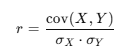

Onde:
* cov(𝑋,𝑌) é a covariância entre X e Y (mede como variam juntas).
* 𝜎𝑋, 𝜎𝑌 são os desvios padrão de X e Y (medem a variabilidade individual).

#📊 Interpretação da força da correlação

Uma classificação comum (Cohen, 1988) é:

* |r| < 0.1 → Desprezível
* 0.1 ≤ |r| < 0.3 → Fraca
* 0.3 ≤ |r| < 0.5 → Moderada
* |r| ≥ 0.5 → Forte

Essa classificação depende da área. Em saúde, por exemplo, até correlações moderadas já podem ser relevantes.

#📌 Exemplo prático

In [3]:
import numpy as np
import pandas as pd

In [6]:
# Dados de exemplo
np.random.seed(42)
n = 800
df = pd.DataFrame({
    "y": np.random.binomial(1, 0.25, n),
    "idade": np.random.normal(40, 12, n),                 # quantitativa
    "pontuacao": np.random.poisson(6, n),                 # quantitativa discreta
})


In [7]:
df

,y,idade,pontuacao
0,0,30.514307,6
1,1,45.657620,6
2,0,62.584294,13
3,0,56.145041,5
4,0,59.118240,8
...,...,...,...
795,1,51.134082,5
796,1,40.684157,9
797,0,43.223107,9
798,0,58.341621,3


#Aplicação da correlação

In [13]:
from scipy.stats import pearsonr

In [20]:
# 1. Correlação de Pearson com p-valor
def calcular_corr_pval(df):
    """
    Calcula matriz de correlação de Pearson e matriz de p-valor.
    Apenas colunas numéricas são consideradas.
    """
    df = df.select_dtypes(include=[np.number]).dropna()
    cols = df.columns
    mat_corr = pd.DataFrame(np.zeros((len(cols), len(cols))), columns=cols, index=cols)
    mat_pval = pd.DataFrame(np.zeros((len(cols), len(cols))), columns=cols, index=cols)

    for i in range(len(cols)):
        for j in range(len(cols)):
            if i == j:
                mat_corr.iloc[i, j] = 1.0
                mat_pval.iloc[i, j] = 0.0
            else:
                r, p = pearsonr(df[cols[i]], df[cols[j]])
                mat_corr.iloc[i, j] = r
                mat_pval.iloc[i, j] = p
    return mat_corr, mat_pval

In [21]:
corr_matrix, pval_matrix = calcular_corr_pval(df)

In [22]:
corr_matrix

,y,idade,pontuacao
y,1.000000,-0.049407,-0.046048
idade,-0.049407,1.000000,0.075229
pontuacao,-0.046048,0.075229,1.000000


In [23]:
pval_matrix

,y,idade,pontuacao
y,0.000000,0.162681,0.193229
idade,0.162681,0.000000,0.033380
pontuacao,0.193229,0.033380,0.000000


#Heatmap da correlação

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

In [24]:
# 2. Heatmap da correlação
def plotar_heatmap(corr_matrix, figsize=(12,8)):
    """
    Plota um heatmap da matriz de correlação.
    """
    plt.figure(figsize=figsize)
    sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False)
    plt.title("Heatmap das Correlações (Pearson)")
    plt.show()

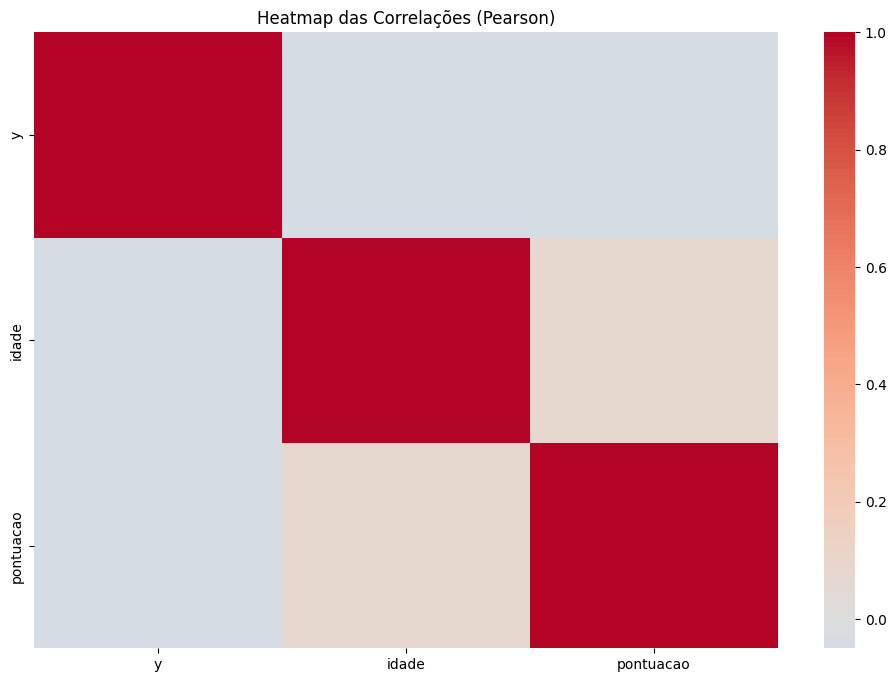

In [26]:
plotar_heatmap(corr_matrix)

#Selecionar correlações com p-valor

In [25]:
# 3. Seleção por p-valor (<0.05)
def filtrar_por_pvalor(corr_matrix, pval_matrix, alpha=0.05):
    """
    Cria tabelas de correlações significativas e não significativas.
    """
    corr_long = corr_matrix.stack().reset_index()
    corr_long.columns = ["Var1", "Var2", "correlacao"]

    pval_long = pval_matrix.stack().reset_index()
    pval_long.columns = ["Var1", "Var2", "pval"]

    df_corr_pval = corr_long.merge(pval_long, on=["Var1", "Var2"])
    df_corr_pval = df_corr_pval[df_corr_pval["Var1"] < df_corr_pval["Var2"]]

    significativos = df_corr_pval[df_corr_pval["pval"] < alpha]
    nao_significativos = df_corr_pval[df_corr_pval["pval"] >= alpha]

    return significativos, nao_significativos

In [28]:
# 3. Seleção por p-valor
significativos, nao_significativos = filtrar_por_pvalor(corr_matrix, pval_matrix, alpha=0.05)

In [29]:
significativos

,Var1,Var2,correlacao,pval
5,idade,pontuacao,0.075229,0.03338


In [30]:
nao_significativos

,Var1,Var2,correlacao,pval
3,idade,y,-0.049407,0.162681
6,pontuacao,y,-0.046048,0.193229


#Classificação da força da correlação

In [31]:
# 4. Classificação da Força da Correlação
def classificar_correlacoes(df_significativos):
    """
    Classifica correlações significativas em Desprezível, Fraca, Moderada, Forte.
    """
    def classificar_forca(r):
        r_abs = abs(r)
        if r_abs < 0.1:
            return "Desprezível"
        elif r_abs < 0.3:
            return "Fraca"
        elif r_abs < 0.5:
            return "Moderada"
        else:
            return "Forte"

    df_significativos = df_significativos.copy()
    df_significativos["forca"] = df_significativos["correlacao"].apply(classificar_forca)
    return df_significativos

In [32]:
# 4. Classificação da força
significativos_classificados = classificar_correlacoes(significativos)

In [33]:
significativos_classificados

,Var1,Var2,correlacao,pval,forca
5,idade,pontuacao,0.075229,0.03338,Desprezível


#Função Final

In [38]:
import plotly.express as px
import plotly.graph_objects as go

In [39]:
def analisar_correlacoes_plotly(df, alpha=0.05, top_n=5, plot=True, heatmap=True):
    """
    Analisa correlações de Pearson entre variáveis numéricas de um DataFrame com gráficos interativos.

    Parâmetros
    ----------
    df : pd.DataFrame
        DataFrame de entrada
    alpha : float, default=0.05
        Nível de significância para considerar p-valor
    top_n : int, default=5
        Quantidade de pares mais correlacionados (em valor absoluto) a exibir
    plot : bool, default=True
        Se True, plota scatterplots interativos dos top_n pares
    heatmap : bool, default=True
        Se True, plota um heatmap interativo da matriz de correlação

    Retorna
    -------
    df_corr : pd.DataFrame
        Tabela com pares de variáveis, r, p-valor, significância e classificação
    """

    # Seleciona apenas variáveis numéricas
    df_num = df.select_dtypes(include=[np.number]).dropna()
    cols = df_num.columns
    resultados = []

    # Função auxiliar para classificar a força da correlação
    def classificar_forca(r):
        r_abs = abs(r)
        if r_abs < 0.1:
            return "Desprezível"
        elif r_abs < 0.3:
            return "Fraca"
        elif r_abs < 0.5:
            return "Moderada"
        else:
            return "Forte"

    # Calcula r e p para cada par
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            r, p = pearsonr(df_num[cols[i]], df_num[cols[j]])
            resultados.append({
                "Var1": cols[i],
                "Var2": cols[j],
                "r": r,
                "p_valor": p,
                "significativo": p < alpha,
                "forca": classificar_forca(r)
            })

    df_corr = pd.DataFrame(resultados)

    # Ordena por correlação absoluta
    df_corr = df_corr.reindex(df_corr["r"].abs().sort_values(ascending=False).index)

    # Mostrar tabela resumida (se disponível no ambiente)
    try:
        from IPython.display import display
        display(df_corr.head(top_n))
    except:
        print(df_corr.head(top_n))

    # Heatmap interativo
    if heatmap:
        corr_matrix = df_num.corr()
        fig = go.Figure(
            data=go.Heatmap(
                z=corr_matrix.values,
                x=corr_matrix.columns,
                y=corr_matrix.columns,
                colorscale="RdBu",
                zmin=-1,
                zmax=1,
                colorbar=dict(title="Correlação")
            )
        )
        fig.update_layout(title="Heatmap das Correlações (Pearson)")
        fig.show()

    # Scatterplots interativos dos top_n pares
    if plot:
        for row in df_corr.head(top_n).itertuples():
            fig = px.scatter(
                df_num,
                x=row.Var1,
                y=row.Var2,
                title=f"{row.Var1} vs {row.Var2} | r={row.r:.2f}, p={row.p_valor:.3g} ({row.forca})",
                opacity=0.7,
                trendline="ols"
            )
            fig.show()

    return df_corr


In [40]:
resultados = analisar_correlacoes_plotly(
    df=df,
    alpha=0.05,
    top_n=3,
    plot=True,
    heatmap=True
)

,Var1,Var2,r,p_valor,significativo,forca
2,idade,pontuacao,0.075229,0.033380,True,Desprezível
0,y,idade,-0.049407,0.162681,False,Desprezível
1,y,pontuacao,-0.046048,0.193229,False,Desprezível


#👉  Cuidados

**Correlação não implica causalidade**

* Duas variáveis podem estar correlacionadas sem uma causar a outra (ex: consumo de sorvete e afogamentos aumentam no verão → variável oculta: temperatura).

**Sensível a outliers**
* Valores extremos podem distorcer o r.

**Linearidade:**
* Pearson só detecta relações lineares; pode ser 0 mesmo havendo relação não linear.

**Variável binária × variável categórica (nominal ou ordinal)**

* Exemplo: internou (0/1) vs faixa de escolaridade (fundamental/médio/superior).
* Aqui você não deve simplesmente fazer encoding arbitrário (tipo transformar as categorias em números 1,2,3 e calcular correlação), porque: O número atribuído não tem significado matemático (não faz sentido dizer “superior = 3” está “três vezes maior que fundamental = 1”). A correlação seria enganosa.
* Métodos corretos: Qui-quadrado / Fisher → testa associação entre categorias, IV/WOE → se o objetivo é seleção preditiva, Cramer’s V → mede força de associação entre duas variáveis categóricas.